# Qwen3-VL + MVTec AD — 산업용 품질 검사 AI 어시스턴트<br>(시각 질의 응답/파이프라인)

[MVTec AD](https://www.mvtec.com/company/research/datasets/mvtec-ad) 데이터셋의 **screw**, **metal_nut** 카테고리를 이용해
**Qwen3-VL-4B-Instruct**로 제조업 품질 검사 Vision+LLM 파이프라인을 구현하는 예제입니다.

| 단계 | 내용 |
|------|------|
| 1 | `MVTec_screw_metal_nut.zip` 압축 해제 & 데이터셋 탐색 |
| 2 | Qwen3-VL 모델 로드 (**Zero-shot** 추론) |
| 3 | **단일 이미지 품질 검사** — 제품 종류·이상 여부·출하 판정 |
| 4 | **결함 비교 분석** — 정상 vs 불량 이미지 동시 입력 |
| 5 | **VLM 기반 결함 유형 분류** |
| 6 | **제조사 품질 검토 회의 시뮬레이션** |
| 7 | **전체 통합 품질 검사 시스템** |
| 8 | **QLoRA 파인튜닝** — MVTec 도메인 SFT & 베이스 vs LoRA 비교 |

<br>

### 실행 경로 (추천)

| 목적 | 실행 범위 | 소요 (RTX 3060 12GB) |
|------|-----------|----------------------|
| Zero-shot 파이프라인만 | §0 → §1~§7 | Qwen3 추론 수분 |
| QLoRA 학습 포함 | §0 → §9 | 학습 약 15~25분 추가 |
| 학습 생략·비교만 | `DO_QLORA=False` → §9-5 | 어댑터 이미 있을 때 |

<br>

> 선행 참고: `06_qwen3_vl_example.ipynb` · `08_qwen3_vl_qlora_fine_tuning.ipynb` · `11_yolo_qwen3_smart_factory_accident_analysis.ipynb`


## 0. 환경 설정

```bash
pip install -r requirements.txt
```

| 패키지 | 용도 |
|--------|------|
| `transformers>=4.57.0` | Qwen3-VL |
| `accelerate` | GPU 모델 로드 |
| `pillow`, `matplotlib` | 이미지 표시 |

<br>

### QLoRA(§9) 추가 패키지

| 패키지 | 용도 |
|--------|------|
| `trl>=0.9.0` | `SFTTrainer` |
| `peft>=0.10.0` | LoRA 어댑터 |
| `bitsandbytes>=0.43.0` | 4bit NF4 양자화 |
| `datasets>=2.18.0` | Hugging Face Dataset |

<br>

> **VRAM 안내**: Zero-shot 추론은 fp16/bf16 기준 **8~10GB**. QLoRA **학습**은 CUDA GPU 필수(약 10~12GB).


In [1]:
%pip install -q "transformers>=4.57.0" accelerate pillow matplotlib

In [2]:
%pip install trl peft bitsandbytes datasets

In [3]:
import json
import re
import shutil
import zipfile
from dataclasses import dataclass, field, asdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from PIL import Image
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

# Colab 실행 여부 감지
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── 경로 ──
ROOT = Path("/content") if IN_COLAB else Path.cwd()
# zip 파일이 상위 폴더에 있을 때 ROOT 자동 보정
if not (ROOT / "MVTec_screw_metal_nut.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "MVTec_screw_metal_nut.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "MVTec_screw_metal_nut.zip"
DATA_ROOT = ROOT / "MVTec_screw_metal_nut"
OUTPUT_DIR = ROOT / "outputs" / "mvtec_quality"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES = ("screw", "metal_nut")

# MVTec AD 결함 유형 한글 라벨
DEFECT_LABELS_KO = {
    "good": "정상",
    "manipulated_front": "전면 변형",
    "scratch_head": "나사 머리 스크래치",
    "scratch_neck": "나사 목 스크래치",
    "thread_side": "나사산 측면 결함",
    "thread_top": "나사산 상단 결함",
    "bent": "휨",
    "color": "색상 이상",
    "flip": "뒤집힘/방향 불량",
    "scratch": "스크래치",
}

# ── Qwen3-VL ──
QWEN_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
MIN_PIXELS = 256 * 28 * 28   # vision 토큰 하한
MAX_PIXELS = 768 * 28 * 28   # vision 토큰 상한 (VRAM 절약)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda" and torch.cuda.is_bf16_supported():
    QWEN_DTYPE = torch.bfloat16
else:
    QWEN_DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32


def setup_korean_font() -> str:
    """matplotlib 한글 폰트 설정. 사용된 폰트명을 반환."""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            plt.rcParams["font.sans-serif"] = [font, "DejaVu Sans"]
            plt.rcParams["axes.unicode_minus"] = False
            return font
    plt.rcParams["axes.unicode_minus"] = False
    print("한글 폰트를 찾지 못했습니다. 제목·본문이 □로 표시될 수 있습니다.")
    return "sans-serif"


KOREAN_FONT = setup_korean_font()
DISPLAY_DPI = 120
plt.rcParams["figure.dpi"] = DISPLAY_DPI
plt.rcParams["savefig.dpi"] = DISPLAY_DPI
print(f"ROOT       : {ROOT.resolve()}")
print(f"ZIP 존재   : {ZIP_PATH.exists()}")
print(f"Device     : {DEVICE}")
print(f"Qwen dtype : {QWEN_DTYPE}")

한글 폰트를 찾지 못했습니다. 제목·본문이 □로 표시될 수 있습니다.
ROOT       : /content
ZIP 존재   : True
Device     : cuda
Qwen dtype : torch.bfloat16


In [4]:
def mvtec_is_ready(root: Path) -> bool:
    """압축 해제가 완료되었는지 screw/metal_nut test/good 폴더로 확인."""
    return (root / "screw" / "test" / "good").exists() and (root / "metal_nut" / "test" / "good").exists()


def normalize_mvtec_root(root: Path) -> Path:
    """zip을 DATA_ROOT 안에 풀어 이중 폴더가 된 경우 내용을 상위로 이동."""
    nested = root / root.name
    if not mvtec_is_ready(nested):
        return root
    for child in nested.iterdir():
        dest = root / child.name
        if dest.exists():
            shutil.rmtree(dest)
        shutil.move(str(child), str(dest))
    shutil.rmtree(nested)
    print(f"데이터셋 경로 정규화 완료: {root.resolve()}")
    return root


def extract_mvtec_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    """MVTec_screw_metal_nut.zip 압축 해제 (이미 있으면 스킵)."""
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일을 찾을 수 없습니다: {zip_path}")
    if not force:
        if mvtec_is_ready(extract_to):
            print("이미 압축 해제됨 — 스킵")
            return
        if mvtec_is_ready(extract_to / extract_to.name):
            normalize_mvtec_root(extract_to)
            print("이미 압축 해제됨 (경로 정규화) — 스킵")
            return
    if force and extract_to.exists():
        shutil.rmtree(extract_to)
    # zip 최상위가 MVTec_screw_metal_nut/ 이므로 ROOT(extract_to.parent)에 해제
    extract_to.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(extract_to.parent)
    normalize_mvtec_root(extract_to)
    if not mvtec_is_ready(extract_to):
        raise FileNotFoundError(
            f"압축 해제 후 데이터셋 구조를 확인할 수 없습니다: {extract_to.resolve()}"
        )
    print(f"압축 해제 완료: {extract_to.resolve()}")


def list_test_images(category: str, defect_type: str | None = None) -> list[Path]:
    """test/ 하위 이미지 경로 목록 반환. defect_type 지정 시 해당 유형만."""
    test_dir = DATA_ROOT / category / "test"
    if defect_type:
        return sorted((test_dir / defect_type).glob("*.png"))
    images = []
    for sub in sorted(test_dir.iterdir()):
        if sub.is_dir():
            images.extend(sorted(sub.glob("*.png")))
    return images


def dataset_summary() -> dict:
    """카테고리별 결함 유형·이미지 수 집계."""
    summary = {}
    for cat in CATEGORIES:
        test_dir = DATA_ROOT / cat / "test"
        summary[cat] = {d.name: len(list(d.glob("*.png"))) for d in sorted(test_dir.iterdir()) if d.is_dir()}
    return summary


def show_image_grid(image_paths: list[Path], titles: list[str] | None = None, ncols: int = 4, figsize=(18, 5)):
    """여러 검사 이미지를 그리드로 시각화."""
    n = len(image_paths)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows), dpi=DISPLAY_DPI)
    axes_flat = [axes] if n == 1 else list(axes.flatten())
    for i, ax in enumerate(axes_flat):
        if i < n:
            img = Image.open(image_paths[i]).convert("RGB")
            ax.imshow(img, interpolation="nearest")
            title = titles[i] if titles else image_paths[i].parent.name
            ax.set_title(title, fontsize=12, fontfamily=KOREAN_FONT)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# 데이터셋 준비 및 통계 출력
extract_mvtec_zip(ZIP_PATH, DATA_ROOT)
summary = dataset_summary()
print(json.dumps(summary, ensure_ascii=False, indent=2))

이미 압축 해제됨 — 스킵
{
  "screw": {
    "good": 41,
    "manipulated_front": 24,
    "scratch_head": 24,
    "scratch_neck": 25,
    "thread_side": 23,
    "thread_top": 23
  },
  "metal_nut": {
    "bent": 25,
    "color": 22,
    "flip": 23,
    "good": 22,
    "scratch": 23
  }
}


=== Screw 샘플 ===


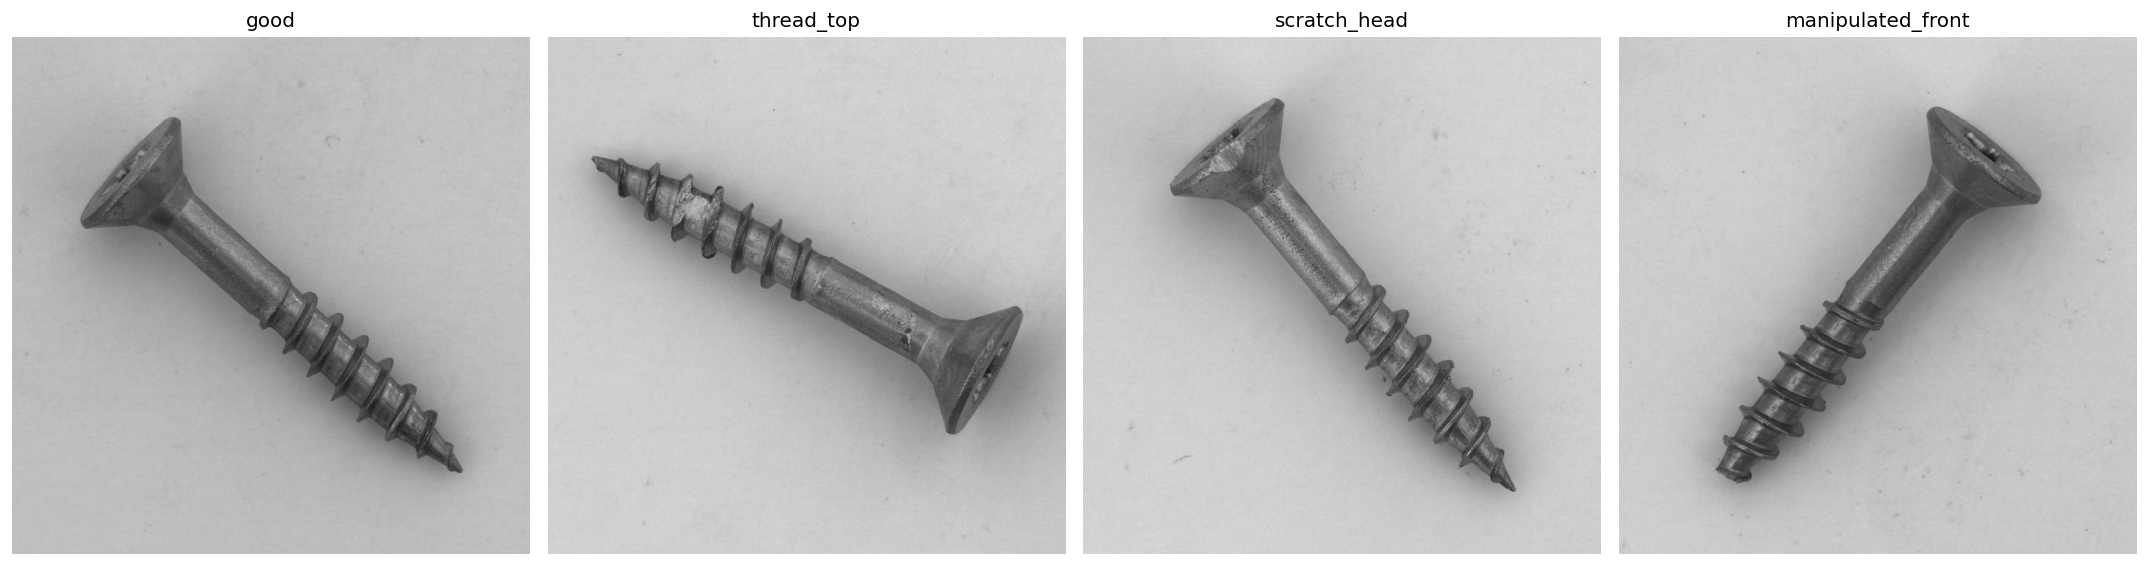

=== Metal Nut 샘플 ===


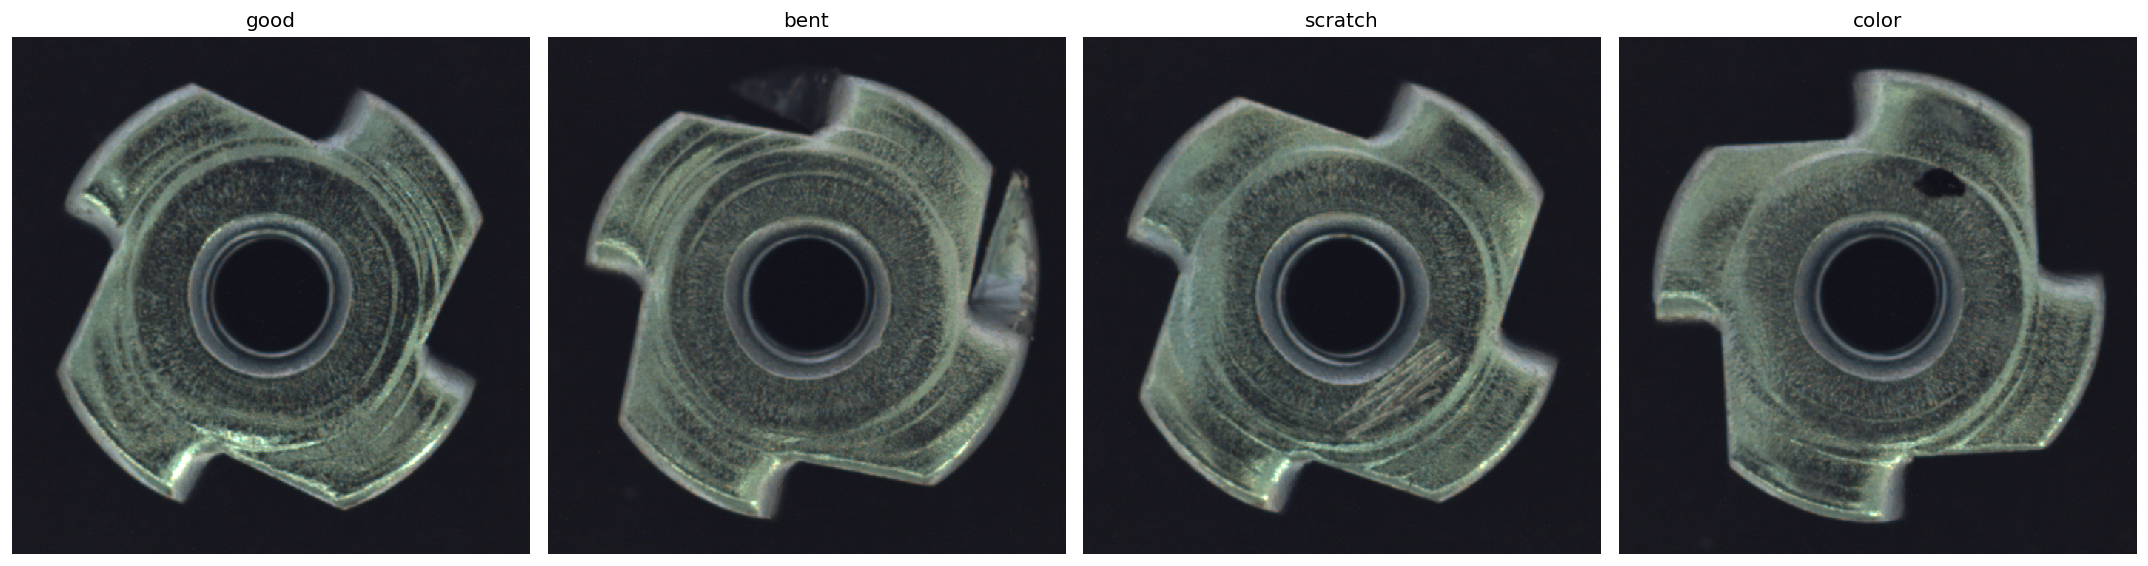

In [5]:
# screw / metal_nut 샘플 이미지 시각화
screw_samples = [
    list_test_images("screw", "good")[0],
    list_test_images("screw", "thread_top")[0],
    list_test_images("screw", "scratch_head")[0],
    list_test_images("screw", "manipulated_front")[0],
]
nut_samples = [
    list_test_images("metal_nut", "good")[0],
    list_test_images("metal_nut", "bent")[0],
    list_test_images("metal_nut", "scratch")[0],
    list_test_images("metal_nut", "color")[0],
]

print("=== Screw 샘플 ===")
show_image_grid(screw_samples, titles=[p.parent.name for p in screw_samples])

print("=== Metal Nut 샘플 ===")
show_image_grid(nut_samples, titles=[p.parent.name for p in nut_samples])

## 2. Qwen3-VL 모델 로드

파인튜닝 없이 Hugging Face Hub의 `Qwen/Qwen3-VL-4B-Instruct`를 그대로 사용합니다.

In [6]:
# accelerate 있으면 device_map="auto"로 GPU 자동 배치
try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False

load_kwargs = {
    "torch_dtype": QWEN_DTYPE,
    "trust_remote_code": True,
}
if has_accelerate and DEVICE == "cuda":
    load_kwargs["device_map"] = "auto"

# Qwen3-VL 프로세서·모델 로드 (파인튜닝 없음)
qwen_processor = AutoProcessor.from_pretrained(
    QWEN_MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
    trust_remote_code=True,
)
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(QWEN_MODEL_ID, **load_kwargs)
if not (has_accelerate and DEVICE == "cuda"):
    qwen_model = qwen_model.to(DEVICE)
qwen_model.eval()

print(f"모델 로드 완료: {QWEN_MODEL_ID}")
print(f"모델 디바이스: {next(qwen_model.parameters()).device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

모델 로드 완료: Qwen/Qwen3-VL-4B-Instruct
모델 디바이스: cuda:0


In [7]:
def decode_qwen(inputs, output_ids) -> str:
    """생성 토큰에서 assistant 응답만 디코딩."""
    trimmed = [out[len(inp):] for inp, out in zip(inputs["input_ids"], output_ids)]
    return qwen_processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()


def move_inputs_to_model(inputs: dict) -> dict:
    """입력 텐서를 모델 디바이스·dtype에 맞게 이동."""
    model_device = next(qwen_model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
        elif key == "pixel_values":
            moved[key] = value.to(model_device, dtype=QWEN_DTYPE)
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_qwen3(
    question: str,
    images: Image.Image | list[Image.Image] | None = None,
    *,
    max_new_tokens: int = 512,
) -> str:
    """Qwen3-VL 단일/다중 이미지 질의응답."""
    if images is None:
        raise ValueError("이미지가 필요합니다.")
    if isinstance(images, Image.Image):
        images = [images]

    # 대화 형식: 이미지(들) + 텍스트 질문
    content = []
    for img in images:
        content.append({"type": "image", "image": img.convert("RGB")})
    content.append({"type": "text", "text": question})

    conversation = [{"role": "user", "content": content}]
    inputs = qwen_processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = move_inputs_to_model(inputs)
    with torch.no_grad():
        output_ids = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return decode_qwen(inputs, output_ids)


def load_image(path: Path | str) -> Image.Image:
    """이미지 파일을 RGB PIL Image로 로드."""
    return Image.open(path).convert("RGB")


def show_large_image(
    image: Image.Image,
    title: str = "",
    *,
    max_width_inch: float = 10.0,
) -> None:
    """검사 이미지를 크게 표시 (MVTec 소형 이미지 확대용)."""
    w, h = image.size
    fig_w = max_width_inch / 2  # 단일 이미지는 기본 대비 50% 크기
    fig_h = max(fig_w * h / max(w, 1), 2.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=DISPLAY_DPI)
    ax.imshow(image, interpolation="nearest")
    if title:
        ax.set_title(title, fontfamily=KOREAN_FONT, fontsize=14, pad=10)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_inspection_result(image: Image.Image, report: str, title: str = "품질 검사"):
    """단일 검사: 큰 이미지 + 텍스트 리포트 출력."""
    show_large_image(image, title=title, max_width_inch=10.0)
    print("\n=== Qwen3-VL 검사 결과 ===")
    print(report)


print("Qwen3-VL 추론 헬퍼 준비 완료")

Qwen3-VL 추론 헬퍼 준비 완료


## 3. 단일 이미지 품질 검사

**입력**: screw 또는 metal_nut 이미지 1장
**프롬프트**: 제조업 품질관리 엔지니어 역할로 5가지 항목 분석

**기대 출력 형식**:
```
부품 종류 : Screw
결함 : ...
심각도 : ...
출하 여부 : ...
권장 조치 : ...
```

In [8]:
# 품질관리 엔지니어 역할 프롬프트 (출력 형식 고정)
QUALITY_INSPECTION_PROMPT = """당신은 제조업 품질관리 엔지니어이다.

이미지를 분석하여 다음 항목을 한국어로 답변하라.

1. 제품 종류
2. 이상 여부
3. 이상 위치
4. 이상 설명
5. 출하 가능 여부

아래 형식을 반드시 지켜라:

부품 종류 :
결함 :
심각도 : (낮음/중간/높음)
출하 여부 : (가능/불가/조건부)
권장 조치 :
"""


def inspect_single_image(image_path: Path | str, title: str | None = None) -> str:
    """이미지 1장 품질 검사 후 리포트 문자열 반환."""
    image = load_image(image_path)
    report = ask_qwen3(QUALITY_INSPECTION_PROMPT, image, max_new_tokens=384)
    show_inspection_result(image, report, title or Path(image_path).parent.name)
    return report

검사 대상: /content/MVTec_screw_metal_nut/screw/test/thread_top/000.png


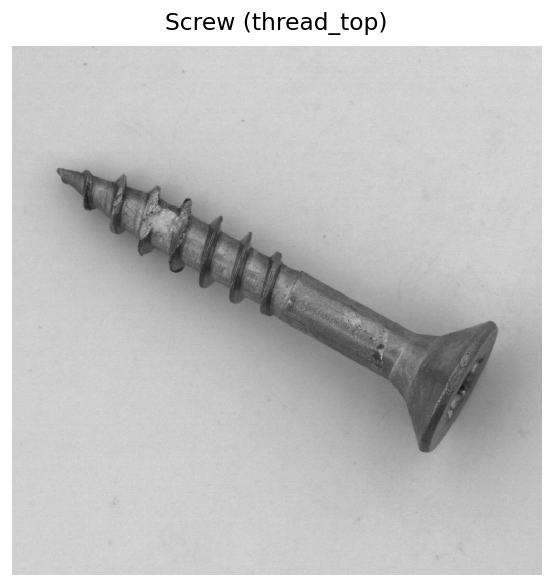


=== Qwen3-VL 검사 결과 ===
부품 종류 : 나사
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 추가 검사 없이 출하 가능.

=== 텍스트 결과 ===
부품 종류 : 나사
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 추가 검사 없이 출하 가능.


In [9]:
# Screw 불량 샘플 검사
screw_defect_path = list_test_images("screw", "thread_top")[0]
print(f"검사 대상: {screw_defect_path}")
screw_report = inspect_single_image(screw_defect_path, title="Screw (thread_top)")
print("\n=== 텍스트 결과 ===")
print(screw_report)

검사 대상: /content/MVTec_screw_metal_nut/metal_nut/test/bent/000.png


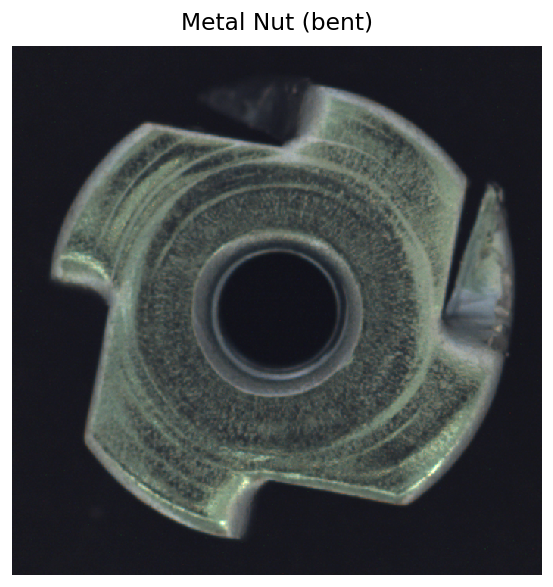


=== Qwen3-VL 검사 결과 ===
부품 종류 : 나사용 볼트(또는 나사용 볼트형 허브)  
결함 : 존재  
심각도 : 중간  
출하 여부 : 조건부  
권장 조치 : 이상 위치(좌측 상단 및 우측 하단)의 파손된 끝부분을 확인하고, 제조 공정에서의 자르기/절단 단계에서 도구 마모 또는 조정 오류로 인한 결함으로 판단되어야 함. 재검사 및 도구 교체 후 재생산 필요. 출하 전 100% 검사 및 품질 보증서 발급 필수.

=== 텍스트 결과 ===
부품 종류 : 나사용 볼트(또는 나사용 볼트형 허브)  
결함 : 존재  
심각도 : 중간  
출하 여부 : 조건부  
권장 조치 : 이상 위치(좌측 상단 및 우측 하단)의 파손된 끝부분을 확인하고, 제조 공정에서의 자르기/절단 단계에서 도구 마모 또는 조정 오류로 인한 결함으로 판단되어야 함. 재검사 및 도구 교체 후 재생산 필요. 출하 전 100% 검사 및 품질 보증서 발급 필수.


In [10]:
# Metal Nut 불량 샘플 검사
nut_defect_path = list_test_images("metal_nut", "bent")[0]
print(f"검사 대상: {nut_defect_path}")
nut_report = inspect_single_image(nut_defect_path, title="Metal Nut (bent)")
print("\n=== 텍스트 결과 ===")
print(nut_report)

## 4. 결함 비교 분석

정상 이미지와 불량 이미지를 **동시에** 입력하여 차이를 설명합니다.

In [11]:
# 정상 vs 불량 2장 비교용 프롬프트
COMPARE_PROMPT = """첫 번째 이미지는 정상 제품, 두 번째 이미지는 검사 대상 제품이다.

질문: 두 이미지의 차이를 설명해줘.

답변 형식:
정상 제품은 ...
불량 제품은 ...
"""


def compare_good_vs_defect(category: str, defect_type: str, index: int = 0) -> str:
    """정상·불량 이미지를 나란히 표시하고 VLM으로 차이 설명."""
    good_path = list_test_images(category, "good")[index]
    defect_path = list_test_images(category, defect_type)[index]

    good_img = load_image(good_path)
    defect_img = load_image(defect_path)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=DISPLAY_DPI)
    axes[0].imshow(good_img, interpolation="nearest")
    axes[0].set_title(f"정상 ({good_path.name})", fontfamily=KOREAN_FONT, fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(defect_img, interpolation="nearest")
    axes[1].set_title(f"불량: {defect_type} ({defect_path.name})", fontfamily=KOREAN_FONT, fontsize=12)
    axes[1].axis("off")
    plt.suptitle(f"{category} — 정상 vs 불량 비교", fontfamily=KOREAN_FONT, fontsize=14)
    plt.tight_layout()
    plt.show()

    answer = ask_qwen3(COMPARE_PROMPT, [good_img, defect_img], max_new_tokens=384)
    print("=== 비교 분석 결과 ===")
    print(answer)
    return answer

/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from 

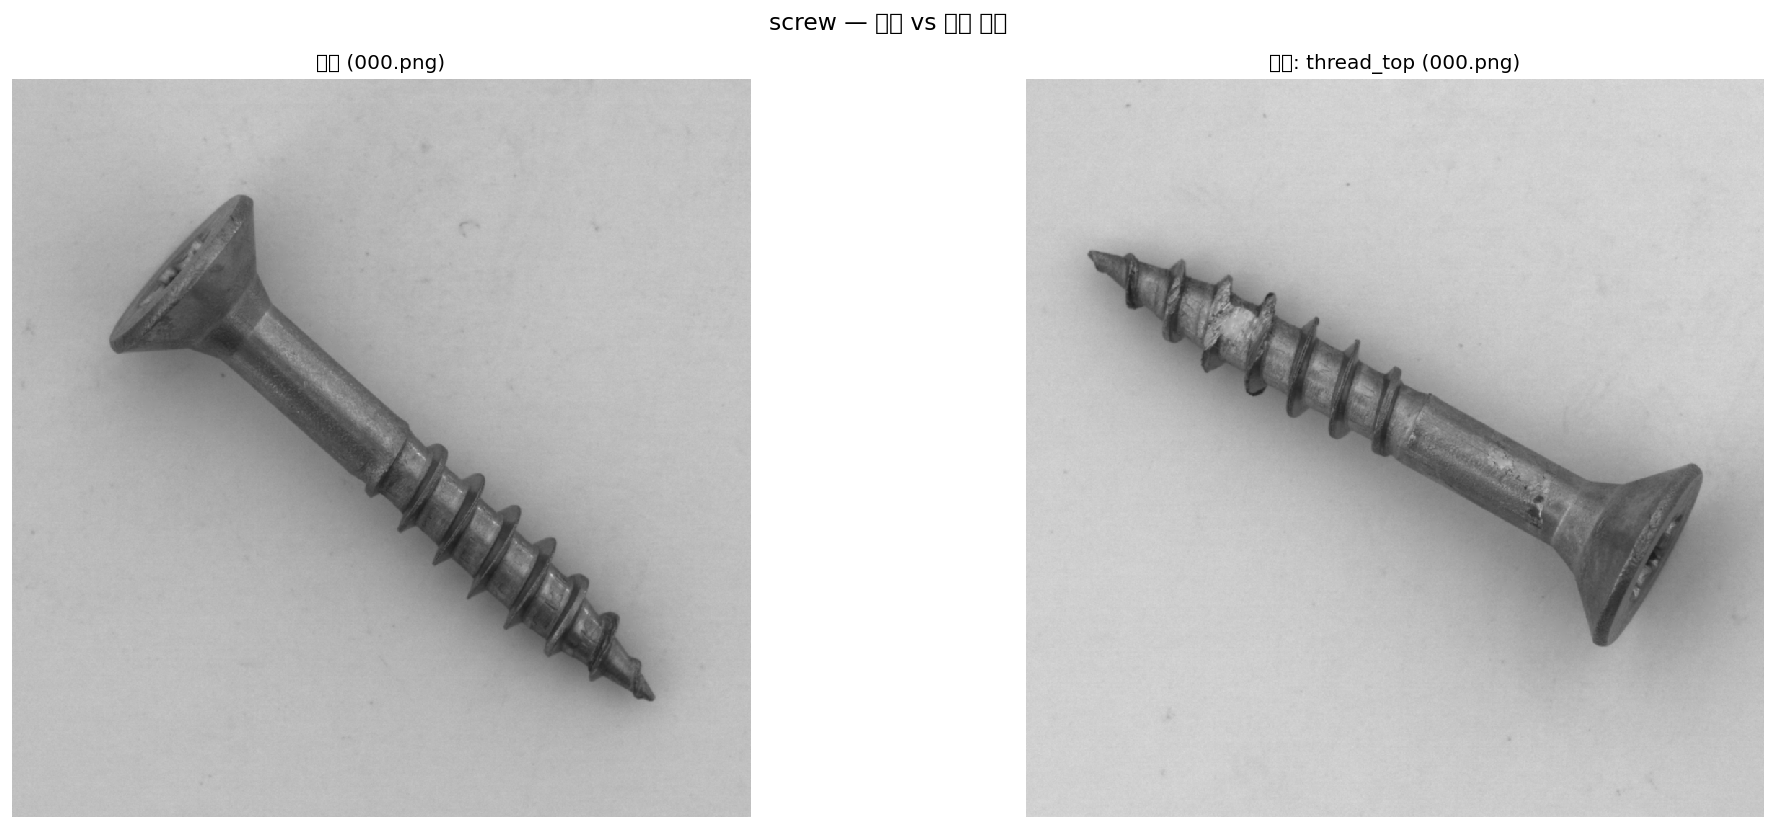

=== 비교 분석 결과 ===
정상 제품은 **조명이 잘 맞춰져 있고, 나사의 전체 구조(볼트, 나사부, 끝부분)가 선명하게 보입니다.**  
불량 제품은 **조명이 어둡고, 나사의 일부가 흐릿하게 보이며, 나사의 구조가 완전히 드러나지 않습니다.**


In [12]:
# Screw: 정상 vs thread_top(나사산 상단 결함)
screw_compare = compare_good_vs_defect("screw", "thread_top", index=0)

/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/293391356.py:28: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


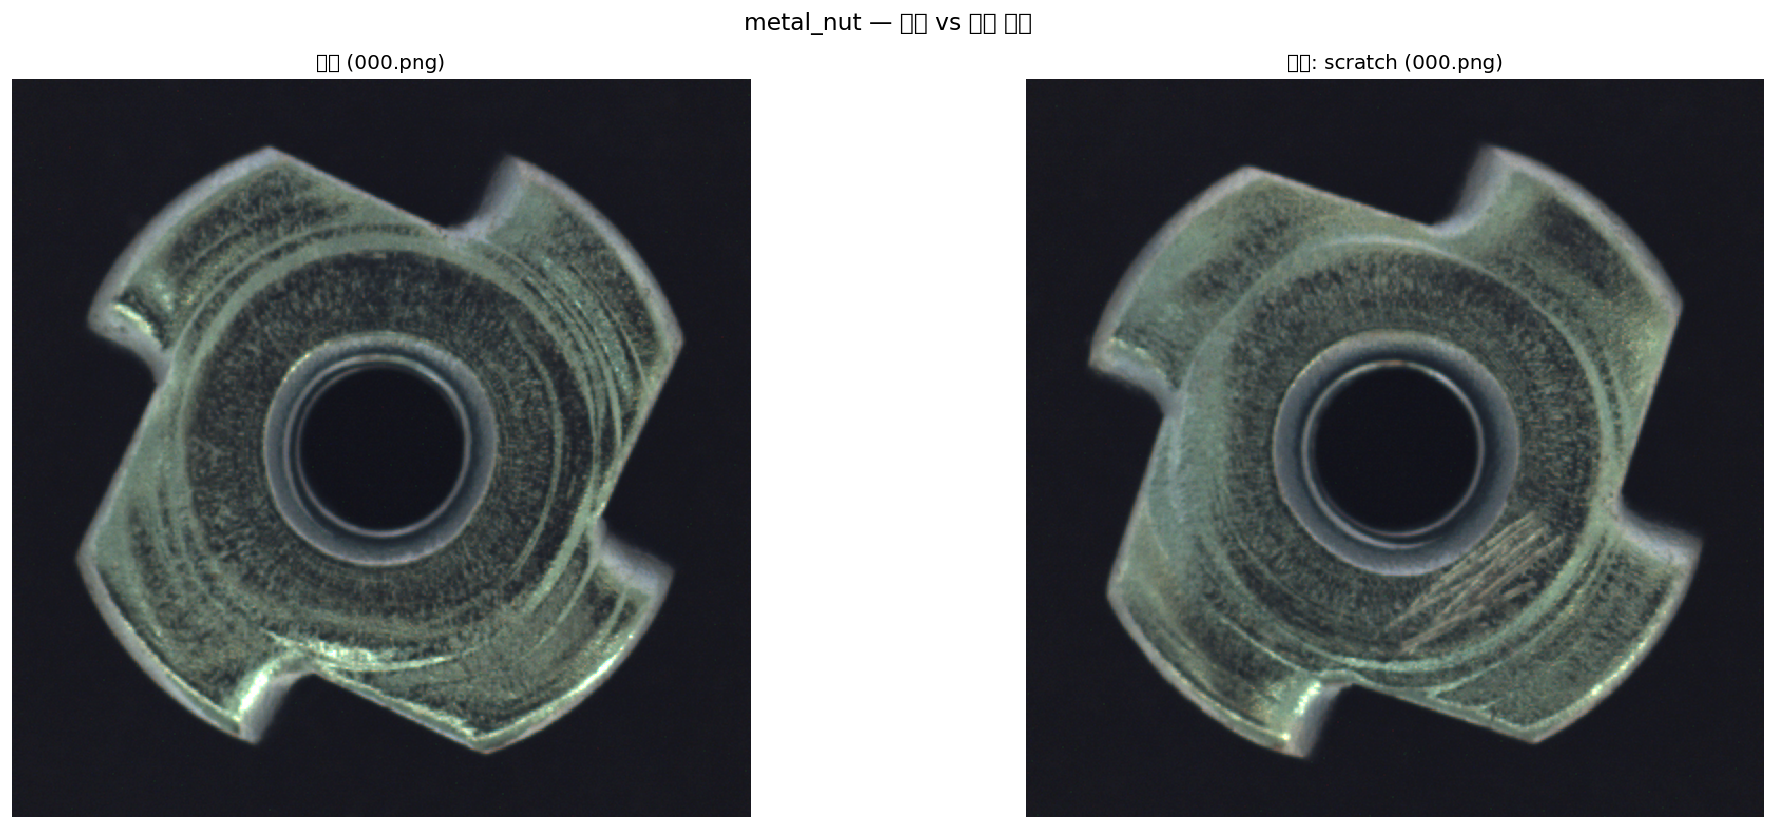

=== 비교 분석 결과 ===
정상 제품은 ...  
불량 제품은 ...  
두 이미지의 주요 차이는 두 번째 이미지(불량 제품)에 **표면에 선명한 금속 마모 또는 흔적**이 있는 점입니다. 이는 정상 제품(첫 번째 이미지)과 비교했을 때, 표면의 완전한 평탄함과 깨끗함이 유지되지 않았음을 의미합니다. 이 마모 또는 흔적은 제품의 사용 또는 제조 과정에서 발생한 손상으로, 품질 기준에 부합하지 않아 불량 제품으로 간주됩니다.


In [13]:
# Metal Nut: 정상 vs scratch
nut_compare = compare_good_vs_defect("metal_nut", "scratch", index=0)

## 5. VLM 기반 결함 유형 분류

Qwen3-VL이 이미지를 보고 MVTec AD 결함 유형 중 하나로 분류하도록 요청합니다.
(Zero-shot — 별도 분류기 학습 없음)

In [14]:
# MVTec AD 결함 유형 목록 (Zero-shot 분류 후보)
SCREW_DEFECT_TYPES = ["good", "manipulated_front", "scratch_head", "scratch_neck", "thread_side", "thread_top"]
NUT_DEFECT_TYPES = ["good", "bent", "color", "flip", "scratch"]


def build_classification_prompt(category: str) -> str:
    """카테고리별 결함 유형 JSON 분류 프롬프트 생성."""
    if category == "screw":
        options = SCREW_DEFECT_TYPES
        product = "나사(Screw)"
    else:
        options = NUT_DEFECT_TYPES
        product = "금속 너트(Metal Nut)"

    option_lines = "\n".join(
        f"- {opt}: {DEFECT_LABELS_KO.get(opt, opt)}" for opt in options if opt != "good"
    )
    return f"""당신은 {product} 품질 검사 전문가이다.

이미지를 보고 아래 결함 유형 중 **가장 적합한 하나**를 고르고, JSON만 출력하라.

결함 유형 목록:
- good: 정상
{option_lines}

출력 형식 (JSON만):
{{
  "predicted_type": "<영문 유형명>",
  "predicted_label_ko": "<한글 설명>",
  "confidence": "<high/medium/low>",
  "reason": "<판단 근거 1~2문장>"
}}
"""


def classify_defect(image_path: Path | str, category: str) -> dict:
    """VLM Zero-shot 결함 유형 분류 → dict (JSON 파싱 실패 시 raw_response)."""
    image = load_image(image_path)
    prompt = build_classification_prompt(category)
    raw = ask_qwen3(prompt, image, max_new_tokens=256)

    text = raw.strip()
    if "```" in text:
        text = re.sub(r"```(?:json)?\s*", "", text)
        text = text.replace("```", "").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"raw_response": raw}

In [15]:
# Screw 결함 유형 분류 (유형별 1장씩 데모)
screw_demo_types = ["good", "scratch_head", "thread_top", "manipulated_front"]
for dtype in screw_demo_types:
    path = list_test_images("screw", dtype)[0]
    pred = classify_defect(path, "screw")
    gt_ko = DEFECT_LABELS_KO.get(dtype, dtype)
    print(f"\n[{dtype} / {gt_ko}] {path.name}")
    print(json.dumps(pred, ensure_ascii=False, indent=2))


[good / 정상] 000.png
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "나사의 머리, 목, 나사산 모두 정상적으로 형성되어 있으며, 결함이나 손상 표시는 없음."
}

[scratch_head / 나사 머리 스크래치] 000.png
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "나사의 머리, 목, 나사산 전체가 정상적으로 형성되어 있으며, 결함이나 변형이 없음."
}

[thread_top / 나사산 상단 결함] 000.png
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "나사의 측면, 머리, 산 부분에 visible 결함이나 손상이 없으며, 전체 구조가 정상적으로 보임."
}

[manipulated_front / 전면 변형] 000.png
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "나사의 머리, 목, 나사산 모두 정상적인 형태와 표면 상태를 보이고, 결함이나 변형이 없음."
}


In [16]:
# Metal Nut 결함 유형 분류 데모
nut_demo_types = ["good", "bent", "flip", "color"]
for dtype in nut_demo_types:
    path = list_test_images("metal_nut", dtype)[0]
    pred = classify_defect(path, "metal_nut")
    gt_ko = DEFECT_LABELS_KO.get(dtype, dtype)
    print(f"\n[{dtype} / {gt_ko}] {path.name}")
    print(json.dumps(pred, ensure_ascii=False, indent=2))


[good / 정상] 000.png
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "너트의 형상과 표면은 정상적으로 유지되어 있으며, 휨, 스크래치, 색상 이상 등 결함은 확인되지 않음."
}

[bent / 휨] 000.png
{
  "predicted_type": "bent",
  "predicted_label_ko": "부품이 휨되어 있는 결함",
  "confidence": "high",
  "reason": "너트의 한쪽 끝이 휨되어 있고, 전체 형태가 비대칭적으로 변형되어 있어 휨 결함으로 판단됨."
}

[flip / 뒤집힘/방향 불량] 000.png
{
  "predicted_type": "color",
  "predicted_label_ko": "색상 이상",
  "confidence": "high",
  "reason": "너트 표면에 녹색 톤의 침식 또는 산화 흔적이 관찰되며, 정상적인 금속 색상과 다름."
}

[color / 색상 이상] 000.png
{
  "predicted_type": "scratch",
  "predicted_label_ko": "스크래치",
  "confidence": "high",
  "reason": "너트 표면에 미세한 스크래치가 관찰되며, 특히 중앙 구멍 주변에 흔적이 명확히 보인다."
}


## 6. 제조사 품질 검토 회의 시뮬레이션

불량 이미지 1장을 근거로 **품질관리(QC) · 생산 · 구매** 담당자가 회의하는 시나리오를 VLM이 생성합니다.

In [17]:
# 품질 검토 회의 시뮬레이션 프롬프트 (QC / 생산 / 구매 역할)
MEETING_PROMPT = """당신은 제조사 품질 검토 회의 진행자이다.

첨부 이미지는 생산 라인에서 검출된 불량 부품이다.
아래 3명의 역할이 **각 1~2문장**으로 의견을 말하는 회의록을 한국어로 작성하라.

역할:
1. 품질관리(QC) 엔지니어 — 결함 원인·심각도 분석
2. 생산 관리자 — 공정·라인 영향, 재발 방지 대책
3. 구매/자재 담당 — 공급사 통보·로트 격리 필요 여부

마지막에 **회의 결론**(출하 보류/폐기/재작업/조건부 출하)을 한 줄로 정리하라.

형식:
[QC] ...
[생산] ...
[구매] ...
[결론] ...
"""


def simulate_quality_meeting(image_path: Path | str, category: str) -> str:
    """불량 이미지 1장으로 품질 검토 회의록 생성·표시."""
    image = load_image(image_path)
    defect_type = Path(image_path).parent.name
    label_ko = DEFECT_LABELS_KO.get(defect_type, defect_type)

    show_large_image(image, title=f"회의 안건: {category} / {label_ko}", max_width_inch=9.0)

    meeting_notes = ask_qwen3(MEETING_PROMPT, image, max_new_tokens=512)
    meeting_md = meeting_notes.replace("\n", "  \n")
    display(Markdown(f"### 품질 검토 회의록\n\n{meeting_md}"))
    return meeting_notes

/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layo

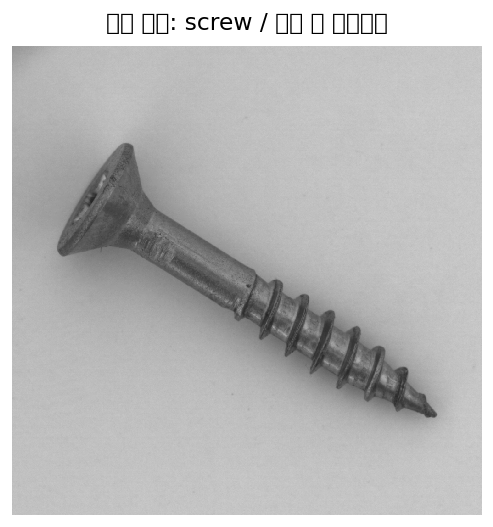

### 품질 검토 회의록

[QC] 이 스크루는 나사 đầu의 표면에 깊은 흔적과 파손이 발생했으며, 사용 시 조립 불량 및 구조적 결함을 유발할 수 있으므로 심각한 불량으로 분류합니다.  
  
[생산] 해당 라인에서의 자동화 장비 점검 부족과 인력 오류로 인한 공정 오류로 추정되며, 즉시 라인 정지 및 재작업 교육을 실시해야 합니다.  
  
[구매] 공급사에 즉시 통보하고, 해당 로트의 재고를 격리하여 품질 검증을 진행해야 하며, 공급사에 대한 공정 개선 요구서를 발송합니다.  
  
[결론] 출하 보류 및 재작업 후 재검증 필수.

In [18]:
# Screw scratch_neck 불량으로 회의 시뮬레이션
meeting_screw_path = list_test_images("screw", "scratch_neck")[0]
screw_meeting = simulate_quality_meeting(meeting_screw_path, "screw")

/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 46244 (\N{HANGUL SYLLABLE DWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 55192 (\N{HANGUL SYLLABLE HIM}) missing from font(s) DejaVu Sans.
  plt.tight_la

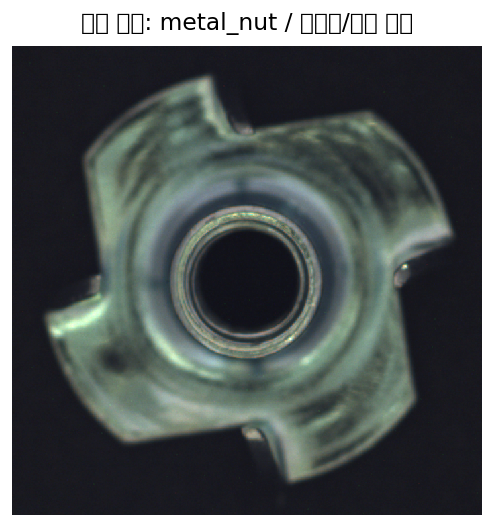

### 품질 검토 회의록

[QC] 이 부품은 중앙 구멍 주변에 녹색 침전물이 축적되어 있어, 공정 중 오염물질 침투 또는 재료 내부 결함으로 판단됩니다. 심각도는 ‘중’이며, 제품 사용 시 기계적 결함 또는 누출 위험을 유발할 수 있습니다.  
  
[생산] 해당 라인에서의 자동 검사 장비가 이 결함을 탐지하지 못했으며, 공정 점검 빈도를 강화하고, 라인 내 오염 방지 절차를 재검토해야 합니다. 재발 방지 대책으로는 공정 전후 청소 절차를 강제화하고, 검사 장비 업그레이드를 추진합니다.  
  
[구매] 공급사에 즉시 통보하고, 해당 로트의 재료를 격리하여 품질 검증을 진행해야 합니다. 공급사의 재료 품질 관리 시스템을 점검하고, 이후 공급 조건을 강화해야 합니다.  
  
[결론] 출하 보류 처리로, 재작업 및 공급사 협의 후 재검토 필요.

In [19]:
# Metal Nut flip 불량으로 회의 시뮬레이션
meeting_nut_path = list_test_images("metal_nut", "flip")[0]
nut_meeting = simulate_quality_meeting(meeting_nut_path, "metal_nut")

## 7. 전체 통합 품질 검사 시스템

단일 클래스 `QualityInspectionSystem`으로 다음 파이프라인을 통합합니다.

1. 단일 이미지 품질 검사 리포트
2. (선택) 정상 기준 이미지와 비교 분석
3. 결함 유형 분류
4. 품질 검토 회의록 생성
5. JSON 리포트 저장

In [20]:
@dataclass
class InspectionReport:
    """통합 품질 검사 결과를 담는 데이터 클래스."""
    timestamp: str
    image_path: str
    category: str
    ground_truth_defect: str
    inspection: str
    comparison: str | None = None
    classification: dict = field(default_factory=dict)
    meeting_notes: str | None = None

    def to_dict(self) -> dict:
        return asdict(self)

    def save(self, output_dir: Path) -> Path:
        """JSON 리포트 파일로 저장."""
        output_dir.mkdir(parents=True, exist_ok=True)
        stem = Path(self.image_path).stem
        out_path = output_dir / f"{self.category}_{stem}_report.json"
        out_path.write_text(json.dumps(self.to_dict(), ensure_ascii=False, indent=2), encoding="utf-8")
        return out_path


class QualityInspectionSystem:
    """단일 검사·비교·분류·회의를 한 번에 실행하는 통합 파이프라인."""

    def __init__(self, category: str):
        if category not in CATEGORIES:
            raise ValueError(f"category는 {CATEGORIES} 중 하나여야 합니다.")
        self.category = category
        self.good_reference = list_test_images(category, "good")[0]

    def run(
        self,
        image_path: Path | str,
        *,
        compare_with_good: bool = True,
        run_meeting: bool = True,
        save: bool = True,
        verbose: bool = True,
    ) -> InspectionReport:
        image_path = Path(image_path)
        image = load_image(image_path)
        defect_type = image_path.parent.name

        if verbose:
            print(f"\n{'='*60}")
            print(f"통합 검사 시작: {self.category} / {image_path.name} (GT: {defect_type})")
            print(f"{'='*60}")

        # 1) 단일 이미지 품질 검사
        inspection = ask_qwen3(QUALITY_INSPECTION_PROMPT, image, max_new_tokens=384)
        if verbose:
            print("\n[1] 품질 검사")
            print(inspection)

        # 2) 정상 기준 이미지와 비교 (선택)
        comparison = None
        if compare_with_good:
            good_img = load_image(self.good_reference)
            comparison = ask_qwen3(COMPARE_PROMPT, [good_img, image], max_new_tokens=384)
            if verbose:
                print("\n[2] 정상 대비 비교")
                print(comparison)

        # 3) 결함 유형 분류
        classification = classify_defect(image_path, self.category)
        if verbose:
            print("\n[3] 결함 유형 분류")
            print(json.dumps(classification, ensure_ascii=False, indent=2))

        # 4) 품질 검토 회의 (불량일 때만)
        meeting_notes = None
        if run_meeting and defect_type != "good":
            meeting_notes = ask_qwen3(MEETING_PROMPT, image, max_new_tokens=512)
            if verbose:
                print("\n[4] 품질 검토 회의")
                print(meeting_notes)

        report = InspectionReport(
            timestamp=datetime.now(timezone.utc).isoformat(),
            image_path=str(image_path),
            category=self.category,
            ground_truth_defect=defect_type,
            inspection=inspection,
            comparison=comparison,
            classification=classification,
            meeting_notes=meeting_notes,
        )

        if save:
            out = report.save(OUTPUT_DIR)
            if verbose:
                print(f"\n리포트 저장: {out}")

        if verbose:
            show_inspection_result(image, inspection, title=f"{self.category} 통합 검사")

        return report


screw_qis = QualityInspectionSystem("screw")
nut_qis = QualityInspectionSystem("metal_nut")
print("QualityInspectionSystem 준비 완료")

QualityInspectionSystem 준비 완료



통합 검사 시작: screw / 000.png (GT: scratch_head)

[1] 품질 검사
부품 종류 : 나사
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 추가 검사 없이 출하 가능.

[2] 정상 대비 비교
정상 제품은 ...  
- 나사 머리의 표면이 매끄럽고, 정교하게 가공된 모습을 보입니다.  
- 나사의 측면과 꼭지 부분에 흔적이나 손상이 없으며, 전체적인 형태가 정확하고 균일합니다.  
- 나사의 홈(조임 부분)이 깊고 정확하게 형성되어 있으며, 사용 시에 잘 작동할 수 있는 상태입니다.

불량 제품은 ...  
- 나사 머리의 표면이 흠집이나 마모, 또는 불규칙한 흔적이 있으며, 가공이 불완전해 보입니다.  
- 나사의 측면에 작은 흔적이 남아 있어, 사용 시에 쉽게 손상될 수 있는 상태입니다.  
- 나사의 홈이 얕거나 불규칙하게 형성되어 있어, 조임이 불편하거나 불완전할 수 있습니다.

[3] 결함 유형 분류
{
  "predicted_type": "good",
  "predicted_label_ko": "정상",
  "confidence": "high",
  "reason": "나사의 머리, 목, 나사산 전체가 정상적으로 형성되어 있으며, 결함이나 변형이 없음."
}

[4] 품질 검토 회의
[QC] 이 스크루는 머리 부분에 깊은 흔적과 표면 마모가 있으며, 공정 중 도구 충돌 또는 품질 제어 점검 미흡으로 인한 결함으로 판단됩니다. 심각도는 중간(3/5)으로, 사용 시 결함이 발생할 수 있으므로 즉각적인 대응 필요.

[생산] 해당 라인에서의 작업자 교육 및 점검 프로세스를 강화하고, 품질 검사 단계를 추가로 체크하여 재발 방지를 위한 공정 개선을 즉시 시행합니다.

[구매] 공급사에 즉시 통보하고, 해당 로트의 재고를 격리하여 품질 검증 후 재평가를 진행해야 합니다. 로트 전체를 재검사 후 출하 여부를 결정합니다.

[결론] 출하 보류 후 재검사 및 공급사 협의 후 재작업 여부 결정.

리포트 저장: /con

/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.1

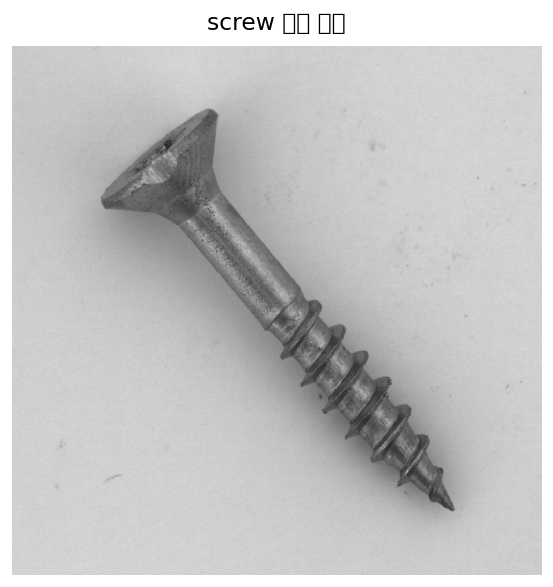


=== Qwen3-VL 검사 결과 ===
부품 종류 : 나사
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 추가 검사 없이 출하 가능.


In [21]:
# Screw 통합 파이프라인 데모
demo_screw = list_test_images("screw", "scratch_head")[0]
screw_full_report = screw_qis.run(demo_screw, compare_with_good=True, run_meeting=True)


통합 검사 시작: metal_nut / 000.png (GT: color)

[1] 품질 검사
부품 종류 : 나사용 허브(또는 허브형 나사못)  
결함 : 존재  
심각도 : 중간  
출하 여부 : 조건부  
권장 조치 : 이상 위치(상부 외곽)의 검은 점은 마모 또는 오염으로 보이며, 제품 사용 시 기능에 직접적인 영향을 주지 않으나, 품질 관리 기준에 부합하지 않음. 출하 전에 해당 부품의 외관 검사 및 정비 여부를 확인하고, 필요 시 정비 후 출하 또는 품질 관리팀과 협의하여 대체 부품 사용 여부 결정.

[2] 정상 대비 비교
정상 제품은 ...  
불량 제품은 ...  
두 이미지의 주요 차이는 두 번째 이미지(불량 제품)에 검사 대상으로 나타난 작은 검은색 얼룩이 있습니다. 이 얼룩은 첫 번째 이미지(정상 제품)에 존재하지 않는 결함으로, 제품의 표면에 불량을 나타내는 시각적 증거입니다.

[3] 결함 유형 분류
{
  "predicted_type": "scratch",
  "predicted_label_ko": "스크래치",
  "confidence": "high",
  "reason": "너트 표면에 미세한 스크래치가 관찰되며, 특히 중앙 구멍 주변에 흔적이 명확히 보인다."
}

[4] 품질 검토 회의
[QC] 이 부품은 중앙 구멍 주변에 미세한 마모와 검은색 결함이 있어, 마찰 또는 충격에 의한 재료 손상으로 추정되며, 사용 시 기계적 결함을 유발할 수 있으므로 심각한 불량입니다.  
[생산] 해당 라인에서의 공정 조건이 일정하게 유지되지 않았고, 재발 방지를 위해 라인 점검 및 자동 감지 시스템 강화를 즉시 실시해야 합니다.  
[구매] 공급사에 즉시 통보하고, 해당 로트를 격리하여 재검사 및 원인 파악을 위한 공급사 협력 요청드립니다.  
[결론] 출하 보류 처리로 결정합니다.

리포트 저장: /content/outputs/mvtec_quality/metal_nut_000_report.json


/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


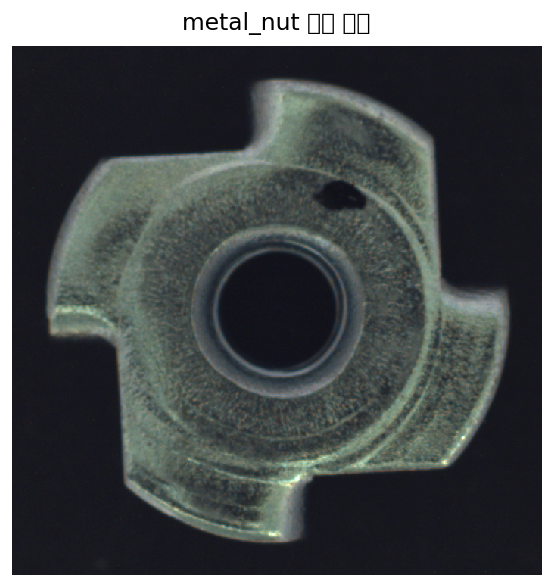


=== Qwen3-VL 검사 결과 ===
부품 종류 : 나사용 허브(또는 허브형 나사못)  
결함 : 존재  
심각도 : 중간  
출하 여부 : 조건부  
권장 조치 : 이상 위치(상부 외곽)의 검은 점은 마모 또는 오염으로 보이며, 제품 사용 시 기능에 직접적인 영향을 주지 않으나, 품질 관리 기준에 부합하지 않음. 출하 전에 해당 부품의 외관 검사 및 정비 여부를 확인하고, 필요 시 정비 후 출하 또는 품질 관리팀과 협의하여 대체 부품 사용 여부 결정.


In [22]:
# Metal Nut 통합 파이프라인 데모
demo_nut = list_test_images("metal_nut", "color")[0]
nut_full_report = nut_qis.run(demo_nut, compare_with_good=True, run_meeting=True)

In [23]:
# 배치 검사: 카테고리별 불량 유형 1장씩 JSON 리포트 생성
batch_targets = [
    ("screw", "thread_side"),
    ("screw", "manipulated_front"),
    ("metal_nut", "bent"),
    ("metal_nut", "scratch"),
]

batch_reports = []
for cat, dtype in batch_targets:
    path = list_test_images(cat, dtype)[0]
    qis = screw_qis if cat == "screw" else nut_qis
    report = qis.run(path, compare_with_good=False, run_meeting=False, verbose=False)
    batch_reports.append(report.to_dict())

batch_out = OUTPUT_DIR / "batch_summary.json"
batch_out.write_text(json.dumps(batch_reports, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"배치 요약 저장: {batch_out}")
print(f"생성된 리포트 수: {len(batch_reports)}")
for r in batch_reports:
    cls = r.get("classification", {})
    pred = cls.get("predicted_type", str(cls.get("raw_response", "?"))[:40])
    print(f"  - {r['category']}/{r['ground_truth_defect']} → 예측: {pred}")

배치 요약 저장: /content/outputs/mvtec_quality/batch_summary.json
생성된 리포트 수: 4
  - screw/thread_side → 예측: good
  - screw/manipulated_front → 예측: good
  - metal_nut/bent → 예측: bent
  - metal_nut/scratch → 예측: scratch


## 9. QLoRA 파인튜닝 — MVTec 품질 검사 특화

앞선 Zero-shot 파이프라인(§1~§7)의 **품질 검사 출력 형식**을 Qwen3-VL이 따르도록
**4bit QLoRA** SFT를 수행합니다. MVTec AD 폴더 라벨(결함 유형)로 **teacher answer**를 규칙 생성합니다.

| 항목 | 설정 |
|------|------|
| 베이스 | `Qwen/Qwen3-VL-4B-Instruct` |
| 방법 | 4bit QLoRA (`bitsandbytes` + `peft` + `trl`) |
| 데이터 | screw + metal_nut test 이미지 (유형별 샘플) |
| 정답 | `QUALITY_INSPECTION_PROMPT` 형식의 규칙 기반 리포트 |
| VRAM | RTX 3060 12GB (`max_pixels` 제한 필수) |
| 출력 | `./qwen3-vl-4b-qlora-mvtec-quality/` |

<br>

> **선행 조건**: §1 데이터 준비·§3 `QUALITY_INSPECTION_PROMPT` 정의 완료.  
> §2에서 로드한 `qwen_model`은 학습 전 GPU 메모리 확보를 위해 해제합니다.  
> `DO_QLORA = False`이면 학습을 건너뛰고 저장된 어댑터만 로드합니다.

### QLoRA 파이프라인

```
MVTec test 이미지 + 폴더명(결함 유형)
    → build_mvtec_sft_samples()  : image_path + teacher 검사 리포트
    → mvtec_collate_fn()         : PIL → chat template → tensor
    → SFTTrainer + peft_config   : 4bit 베이스 + LoRA 학습
    → qwen3-vl-4b-qlora-mvtec-quality/  : adapter + processor 저장
    → PeftModel + disable_adapter(): 베이스 vs LoRA 비교 추론
```

### 추가 패키지

```bash
pip install trl peft bitsandbytes datasets
```

| 패키지 | 용도 |
|--------|------|
| `trl>=0.9.0` | `SFTTrainer` |
| `peft>=0.10.0` | LoRA 어댑터 |
| `bitsandbytes>=0.43.0` | 4bit NF4 양자화 |
| `datasets>=2.18.0` | Hugging Face Dataset |

In [24]:
# %pip install -q trl peft bitsandbytes datasets

# [QLoRA 하이퍼파라미터] DO_QLORA: 학습 실행 | QLORA_OUTPUT_DIR: 어댑터 저장 경로
import gc
import inspect
import time

from datasets import Dataset
from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen3VLForConditionalGeneration
from trl import SFTConfig, SFTTrainer

# ── 학습 제어 플래그 ──
DO_QLORA = True   # False: 학습 건너뛰고 기존 어댑터만 사용 (비교 추론용)
QLORA_OUTPUT_DIR = ROOT / "qwen3-vl-4b-qlora-mvtec-quality"
QLORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── SFT 하이퍼파라미터 (RTX 3060 12GB 기준) ──
NUM_EPOCHS = 3          # epoch 수 — 데이터가 작으므로 3~5 권장
BATCH_SIZE = 1          # VLM은 이미지당 메모리가 커서 1 고정
GRAD_ACCUM = 4          # 유효 배치 = 1×4 = 4
LEARNING_RATE = 2e-4    # LoRA 일반적 학습률
LORA_R = 8              # LoRA rank (낮을수록 파라미터·VRAM 절약)
LORA_ALPHA = 16         # LoRA scaling (보통 r의 2배)
MAX_PER_TYPE = 2                     # 결함 유형별 학습 샘플 수
TRAIN_MAX_PIXELS = 256 * 28 * 28     # 학습 vision 토큰 상한
TRAIN_MIN_PIXELS = 256 * 28 * 28     # 학습 vision 토큰 하한 (OOM 방지)

# SFT system 역할 — assistant 톤·도메인 고정
QLORA_SYSTEM_PROMPT = (
    "당신은 제조업 품질관리 AI 어시스턴트입니다. "
    "부품 이미지를 분석하여 결함·출하 여부를 한국어로 보고합니다."
)

# §2 추론 모델 해제 → QLoRA 학습용 VRAM 확보
# 4bit QLoRA 베이스만으로도 ~7GB 필요 — 기존 fp16 VLM과 동시 상주 불가
for _name in ("qwen_model", "qwen_processor"):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU 메모리 확보: {torch.cuda.memory_allocated()/1024**3:.2f} GB 사용 중")
print(f"DO_QLORA={DO_QLORA} | 출력: {QLORA_OUTPUT_DIR.resolve()}")

GPU 메모리 확보: 0.01 GB 사용 중
DO_QLORA=True | 출력: /content/qwen3-vl-4b-qlora-mvtec-quality


### 9-1. 학습 데이터셋 구축

MVTec AD `test/<결함유형>/` 폴더명을 ground truth로 사용하고,
§3과 동일한 `QUALITY_INSPECTION_PROMPT` 형식의 **teacher 리포트**를 규칙 기반 생성합니다.

> PIL Image는 Dataset 저장 시 직렬화 이슈가 있으므로 **`image_path`만 저장**하고 `collate_fn`에서 로드합니다.

In [25]:
# [SFT 데이터셋] 폴더명 결함 유형 → teacher 품질 검사 리포트 생성
def build_teacher_inspection_answer(category: str, defect_type: str) -> str:
    """MVTec 폴더명(GT)으로 §3과 동일 형식의 teacher 정답 문자열 생성."""
    product = "Screw" if category == "screw" else "Metal Nut"
    if defect_type == "good":
        # 정상 샘플 — 출하 가능 판정
        return (
            f"부품 종류 : {product}\n"
            "결함 : 없음\n"
            "심각도 : 낮음\n"
            "출하 여부 : 가능\n"
            "권장 조치 : 정상 출하"
        )

    label_ko = DEFECT_LABELS_KO.get(defect_type, defect_type)
    # 심각 결함 유형 — 출하 불가·폐기 권고
    severe = defect_type in {"manipulated_front", "bent", "flip"}
    severity = "높음" if severe else "중간"
    action = "폐기 또는 재가공" if severe else "선별 후 재검 또는 폐기"
    return (
        f"부품 종류 : {product}\n"
        f"결함 : {label_ko}\n"
        f"심각도 : {severity}\n"
        "출하 여부 : 불가\n"
        f"권장 조치 : {action}"
    )


def build_mvtec_sft_samples(max_per_type: int = MAX_PER_TYPE) -> list[dict]:
    """screw/metal_nut test 이미지를 (image_path, prompt, answer) SFT 레코드로 변환."""
    samples = []
    for category in CATEGORIES:
        test_dir = DATA_ROOT / category / "test"
        for defect_dir in sorted(test_dir.iterdir()):
            if not defect_dir.is_dir():
                continue
            dtype = defect_dir.name  # 폴더명 = 결함 유형 ground truth
            for img_path in sorted(defect_dir.glob("*.png"))[:max_per_type]:
                # PIL Image는 Dataset 직렬화 이슈 → 경로만 저장, collate_fn에서 로드
                samples.append({
                    "image_path": str(img_path.resolve()),
                    "user_prompt": QUALITY_INSPECTION_PROMPT,
                    "answer": build_teacher_inspection_answer(category, dtype),
                    "category": category,
                    "defect_type": dtype,
                })
    return samples


def build_train_messages(image: Image.Image, user_prompt: str, answer: str) -> list[dict]:
    """Qwen3-VL SFT용 system/user/assistant 3턴 messages 구성."""
    return [
        {"role": "system", "content": [{"type": "text", "text": QLORA_SYSTEM_PROMPT}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_prompt},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": answer}]},
    ]


sft_records = build_mvtec_sft_samples()
train_dataset = Dataset.from_list(sft_records)
print(f"SFT train 샘플: {len(train_dataset)}")
print("예시:", train_dataset[0]["category"], train_dataset[0]["defect_type"])
print("assistant 미리보기:\n", train_dataset[0]["answer"])

SFT train 샘플: 22
예시: screw good
assistant 미리보기:
 부품 종류 : Screw
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 정상 출하


### 9-2. 4bit QLoRA 모델 로드

- `prepare_model_for_kbit_training`: gradient checkpointing 등 k-bit 학습 준비
- `patch_input_embeddings`: Qwen3-VL + checkpointing 호환 패치
- `freeze_vision_modules`: visual encoder 동결 (LoRA는 LLM만 학습)

In [26]:
# [QLoRA 모델 준비] 4bit 베이스 + LoRA config
def clear_gpu():
    # 학습/추론 모델 교체 시 VRAM 해제
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def freeze_vision_modules(model):
    # visual encoder는 동결 — LoRA는 LLM attention만 학습 (VRAM·시간 절약)
    for name, param in model.named_parameters():
        if "visual" in name or "vision" in name:
            param.requires_grad = False


def patch_input_embeddings(model):
    # Qwen3-VL + gradient checkpointing 시 get_input_embeddings NotImplementedError 방지
    inner = model.get_model() if hasattr(model, "get_model") else model.model
    if not hasattr(inner, "get_input_embeddings") or inner.get_input_embeddings() is None:
        def get_input_embeddings(self):
            return self.language_model.get_input_embeddings()
        inner.get_input_embeddings = get_input_embeddings.__get__(inner, type(inner))


def configure_qwen3_processor(processor, min_pixels: int, max_pixels: int):
    # 학습·추론 시 vision 토큰 수 상·하한 설정
    processor.image_processor.min_pixels = min_pixels
    processor.image_processor.max_pixels = max_pixels
    if hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {"shortest_edge": min_pixels, "longest_edge": max_pixels}
    return processor


if not DO_QLORA and (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    print("DO_QLORA=False — 기존 어댑터 사용:", QLORA_OUTPUT_DIR)
else:
    # NF4 4bit 양자화 — 12GB GPU에서 4B VLM 학습 가능하게 함
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    qlora_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    qlora_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    qlora_processor = configure_qwen3_processor(qlora_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

    # k-bit 학습 준비 + gradient checkpointing
    qlora_model = prepare_model_for_kbit_training(qlora_model, use_gradient_checkpointing=True)
    qlora_model.config.use_cache = False  # 학습 시 KV cache 비활성
    patch_input_embeddings(qlora_model)
    freeze_vision_modules(qlora_model)

    # LoRA: LLM attention q_proj, v_proj에만 저랭크 어댑터 부착
    peft_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_proj", "v_proj"],
        task_type="CAUSAL_LM",
    )

    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"QLoRA 모델 로드 | GPU: {allocated:.2f} GB")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


QLoRA 모델 로드 | GPU: 3.45 GB


### 9-3. collate_fn & SFTTrainer

- VLM은 `max_length=None` — truncation 시 vision 토큰 불일치 방지
- `mask_vision_tokens`: vision 특수 토큰 labels `-100` 마스킹

In [27]:
# [SFTTrainer 설정] mvtec_collate_fn: image_path → PIL → processor tensor
def mask_vision_tokens(labels, tokenizer):
    # vision 특수 토큰은 loss 계산에서 제외 (labels=-100)
    for token in ("<|vision_start|>", "<|vision_end|>", "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>"):
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            labels[labels == token_id] = -100
    return labels


def mvtec_collate_fn(examples):
    # 배치 1 step: 경로→PIL→chat template→input_ids·pixel_values·labels
    messages_list, images = [], []
    for ex in examples:
        img = Image.open(ex["image_path"]).convert("RGB")
        messages_list.append(build_train_messages(img, ex["user_prompt"], ex["answer"]))
        images.append([img])
    texts = [qlora_processor.apply_chat_template(m, tokenize=False) for m in messages_list]
    batch = qlora_processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    labels[labels == qlora_processor.tokenizer.pad_token_id] = -100  # padding 마스킹
    labels = mask_vision_tokens(labels, qlora_processor.tokenizer)
    batch["labels"] = labels
    return batch


if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    sft_kwargs = dict(
        output_dir=str(QLORA_OUTPUT_DIR),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        optim="paged_adamw_8bit",       # 8bit AdamW — VRAM 절약
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        logging_steps=4,
        save_strategy="epoch",
        eval_strategy="no",
        fp16=False,                     # QLoRA+PEFT와 AMP dtype 충돌 방지
        bf16=False,
        max_grad_norm=0.3,
        report_to="none",
        remove_unused_columns=False,
        dataset_kwargs={"skip_prepare_dataset": True},  # VLM은 collate_fn이 직접 처리
        dataloader_num_workers=0,
        max_length=None,                # truncation 금지 — vision 토큰 잘림 방지
        assistant_only_loss=False,
    )
    training_args = SFTConfig(**sft_kwargs)
    print("SFTConfig 준비 완료")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


SFTConfig 준비 완료


/tmp/ipykernel_6634/1043195504.py:52: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(**sft_kwargs)


### 9-4. QLoRA 학습 실행 & 어댑터 저장

학습 완료 후 `adapter_config.json`, LoRA 가중치, processor가 `QLORA_OUTPUT_DIR`에 저장됩니다.  
재학습 없이 §9-5만 실행하려면 `DO_QLORA=False`로 설정하세요.

In [28]:
# [QLoRA 학습 실행] trainer.train() → adapter 저장
if DO_QLORA or not (QLORA_OUTPUT_DIR / "adapter_config.json").exists():
    trainer_kwargs = dict(
        model=qlora_model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=mvtec_collate_fn,
        peft_config=peft_config,  # SFTTrainer가 LoRA 어댑터 자동 부착
    )
    # transformers/trl 버전별 인자명 호환
    if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters:
        trainer_kwargs["processing_class"] = qlora_processor
    else:
        trainer_kwargs["tokenizer"] = qlora_processor.tokenizer

    trainer = SFTTrainer(**trainer_kwargs)

    print("=" * 50)
    print("QLoRA 학습 시작 (MVTec 품질 검사)")
    t0 = time.time()
    train_result = trainer.train()  # 실제 역전파·LoRA 가중치 업데이트
    print("=" * 50)
    print(f"학습 완료 | {(time.time()-t0)/60:.1f}분 | loss={train_result.training_loss:.4f}")

    # LoRA adapter + processor만 저장 (베이스 4B 전체는 저장하지 않음)
    trainer.save_model(str(QLORA_OUTPUT_DIR))
    qlora_processor.save_pretrained(str(QLORA_OUTPUT_DIR))
    print(f"어댑터 저장: {QLORA_OUTPUT_DIR.resolve()}")

    del trainer, qlora_model
    clear_gpu()
else:
    print("학습 스킵 (DO_QLORA=False, 어댑터 존재)")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


QLoRA 학습 시작 (MVTec 품질 검사)


Step,Training Loss
4,2.398464
8,1.886627
12,1.575481
16,1.420828


학습 완료 | 0.9분 | loss=1.7733
어댑터 저장: /content/qwen3-vl-4b-qlora-mvtec-quality


### 9-5. LoRA vs 베이스 — 품질 검사 리포트 비교

불량 샘플 1장에 대해 **베이스 Qwen3-VL**과 **QLoRA 어댑터**의 검사 리포트를 비교합니다.

- **베이스**: `disable_adapter()` — 4bit 원본
- **LoRA**: adapter ON — §9에서 학습한 MVTec 특화 가중치

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


비교 이미지: 000.png | GT: thread_top


/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6634/2457643247.py:73: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

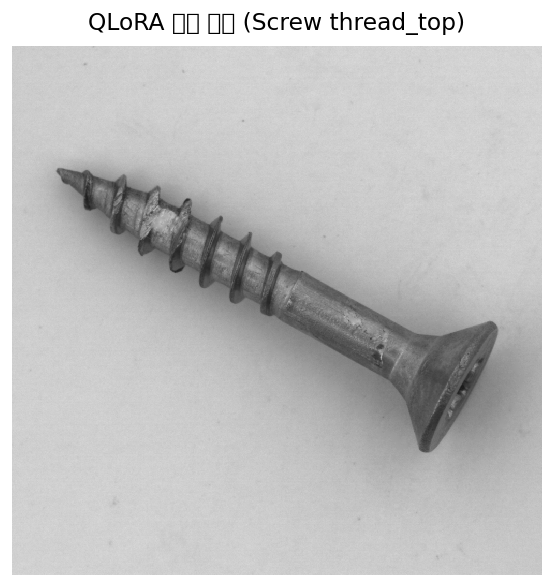


--- 베이스 Qwen3-VL (adapter OFF) ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


부품 종류 : 나사
결함 : 없음
심각도 : 낮음
출하 여부 : 가능
권장 조치 : 출하 가능. 특별한 이상 없음.

--- QLoRA 어댑터 (adapter ON) ---
부품 종류 : 나사
결함 : 금속 마모 및 표면 손상
심각도 : 중간
출하 여부 : 불가
권장 조치 : 재검사 및 재처리 후 출하 또는 교체 부품 사용 권장

--- Teacher 정답 (학습 라벨) ---
부품 종류 : Screw
결함 : 나사산 상단 결함
심각도 : 중간
출하 여부 : 불가
권장 조치 : 선별 후 재검 또는 폐기


In [29]:
# [추론 비교] PeftModel 로드 → 베이스 vs LoRA 품질 검사 리포트
INFER_DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32  # bf16+4bit visual Conv3d CUDA 오류 방지

clear_gpu()
bnb_infer = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=INFER_DTYPE,
    bnb_4bit_use_double_quant=True,
)

# 4bit 베이스 + 학습된 LoRA 어댑터 로드
base_4bit = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    quantization_config=bnb_infer,
    device_map="auto",
    torch_dtype=INFER_DTYPE,
)
infer_processor = AutoProcessor.from_pretrained(QLORA_OUTPUT_DIR)
infer_processor = configure_qwen3_processor(infer_processor, TRAIN_MIN_PIXELS, TRAIN_MAX_PIXELS)

lora_model = PeftModel.from_pretrained(base_4bit, str(QLORA_OUTPUT_DIR))
lora_model.eval()

# 비교 대상: screw thread_top 불량 샘플
compare_path = list_test_images("screw", "thread_top")[0]
compare_image = load_image(compare_path)
print(f"비교 이미지: {compare_path.name} | GT: thread_top")
show_large_image(compare_image, title="QLoRA 비교 대상 (Screw thread_top)")


def qlora_generate(model, processor, image: Image.Image, question: str, max_new_tokens: int = 384) -> str:
    """4bit+LoRA 모델 단일 이미지 추론 — assistant 응답만 반환."""
    conversation = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    }]
    inputs = processor.apply_chat_template(
        conversation, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
    )
    inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k, v in inputs.items()}
    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(INFER_DTYPE)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs["input_ids"], out_ids)]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


print("\n--- 베이스 Qwen3-VL (adapter OFF) ---")
with lora_model.disable_adapter():
    base_answer = qlora_generate(lora_model, infer_processor, compare_image, QUALITY_INSPECTION_PROMPT)
print(base_answer)

print("\n--- QLoRA 어댑터 (adapter ON) ---")
lora_answer = qlora_generate(lora_model, infer_processor, compare_image, QUALITY_INSPECTION_PROMPT)
print(lora_answer)

# teacher 정답과 형식·내용 비교 참고
print("\n--- Teacher 정답 (학습 라벨) ---")
print(build_teacher_inspection_answer("screw", "thread_top"))

## 10. 요약

| 기능 | 설명 |
|------|------|
| 데이터 로딩 | `MVTec_screw_metal_nut.zip` 해제, screw/metal_nut 샘플 시각화 |
| Zero-shot 검사 | Qwen3-VL 품질 판정 (부품·결함·출하 여부) |
| 비교 분석 | 정상+불량 2장 동시 입력 차이 설명 |
| 유형 분류 | MVTec 결함 유형 JSON 분류 |
| 회의 시뮬레이션 | QC/생산/구매 역할 회의록 |
| 통합 시스템 | `QualityInspectionSystem` — 전 단계 + JSON 저장 |
| **QLoRA SFT** | MVTec teacher 리포트로 도메인 미세조정, 베이스 vs LoRA 비교 |

<br>

> **Zero-shot 한계**: 산업 검사 벤치마크 대비 정확도가 제한적입니다.  
> §9 QLoRA로 출력 형식·도메인 용어를 맞추면 실무 리포트 품질이 개선됩니다.  
> 대규모 SFT는 `08_qwen3_vl_qlora_fine_tuning.ipynb`(KoLLaVA 1.5k)를 참고하세요.